In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import math

# Add project root to Python path
project_root = Path().resolve().parent
sys.path.append(str(project_root))
from src import config

In [2]:
from src.data.load_data import load_dataset
from src.data.preprocess import create_yearly_longevity_category

In [3]:
df = load_dataset()

In [4]:
config.TARGET_COLUMN
df.shape

(100000, 28)

### Columns type

In [5]:
df.dtypes

pair_id                            int64
a_age                              int64
a_education                        int64
a_location                           str
a_career_field                       str
a_career_ambition                float64
a_openness                       float64
a_extraversion                   float64
a_agreeableness                  float64
a_conscientiousness              float64
a_chronotype                     float64
a_spontaneity                    float64
a_love_language                      str
a_emotional_expressiveness       float64
b_age                              int64
b_education                        int64
b_location                           str
b_career_field                       str
b_career_ambition                float64
b_openness                       float64
b_extraversion                   float64
b_agreeableness                  float64
b_conscientiousness              float64
b_chronotype                     float64
b_spontaneity   

# Visualizations & Sanity checks

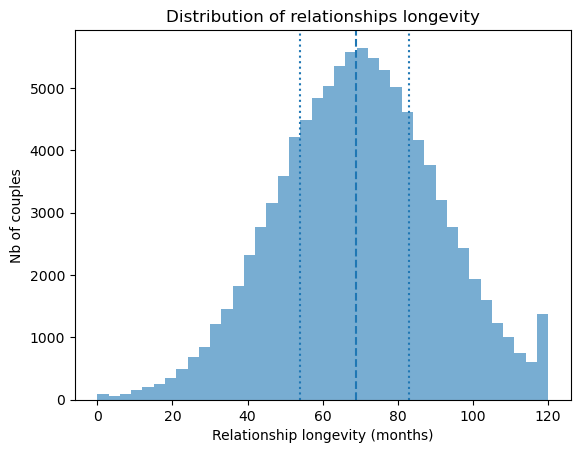

In [6]:
target = df[config.TARGET_COLUMN]

mean_val = target.mean()
median_val = target.median()
q25 = target.quantile(0.25)
q75 = target.quantile(0.75)
min_val = target.min()
max_val = target.max()

plt.figure()

plt.hist(target, bins=40, alpha=0.6)

plt.axvline(mean_val, linestyle="--", label=f"Mean ({mean_val:.1f})")
#plt.axvline(median_val, linestyle="-", label=f"Median ({median_val:.1f})")
plt.axvline(q25, linestyle=":", label=f"25% ({q25:.0f})")
plt.axvline(q75, linestyle=":", label=f"75% ({q75:.0f})")

plt.xlabel("Relationship longevity (months)")
plt.ylabel("Nb of couples")
plt.title("Distribution of relationships longevity")
plt.show()

## Data distribution

The Data is cleanly distributed (skewness and kurtosis close to 0). This is actually surprizing as one would wonder why couples would tend to break up around the 70th month of their relationship (around the end of the 5th year). 
Given that the dataset originates from Kaggle and was generated for pedagogical purposes, this near-Gaussian shape likely reflects synthetic data generation rather than genuine behavioral patterns, and therefore does not reflect the reality of the Unfathomable Ways of Love.

## Empty values 

In [7]:
df.isna().sum().sort_values(ascending=False).head(15)

pair_id                       0
a_age                         0
a_education                   0
a_location                    0
a_career_field                0
a_career_ambition             0
a_openness                    0
a_extraversion                0
a_agreeableness               0
a_conscientiousness           0
a_chronotype                  0
a_spontaneity                 0
a_love_language               0
a_emotional_expressiveness    0
b_age                         0
dtype: int64

None ! This is great (and rare!).

## Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

Cool, there is no duplicates.

## Existence of correlations 

In [9]:
df.corr(numeric_only=True)[config.TARGET_COLUMN].sort_values(ascending=False)

relationship_longevity_months    1.000000
a_extraversion                   0.003680
b_extraversion                   0.003517
a_agreeableness                  0.003254
b_conscientiousness              0.002881
a_conscientiousness              0.002293
b_chronotype                     0.002248
a_chronotype                     0.001680
a_emotional_expressiveness       0.001124
b_age                            0.000635
a_education                      0.000302
a_spontaneity                    0.000046
a_age                            0.000002
b_education                     -0.000024
pair_id                         -0.000410
a_openness                      -0.000651
b_spontaneity                   -0.000951
b_career_ambition               -0.001581
a_career_ambition               -0.001804
b_openness                      -0.002818
b_emotional_expressiveness      -0.003253
b_agreeableness                 -0.003971
Name: relationship_longevity_months, dtype: float64

The low correlations (<0.01) with all raw variables indicate the absence of any strong linear relationship with the target variable. Which is at this point quite normal since the data only provides information at an individual level (columns a_ and b_). We haven't started looking at relationship caracteristics yet which we will be doing further when exploring features. 

Given the absence of strong correlations between the target and the raw variables, we can also reasonably exclude the presence of direct data leakage.

## Barplots for data distribution checks

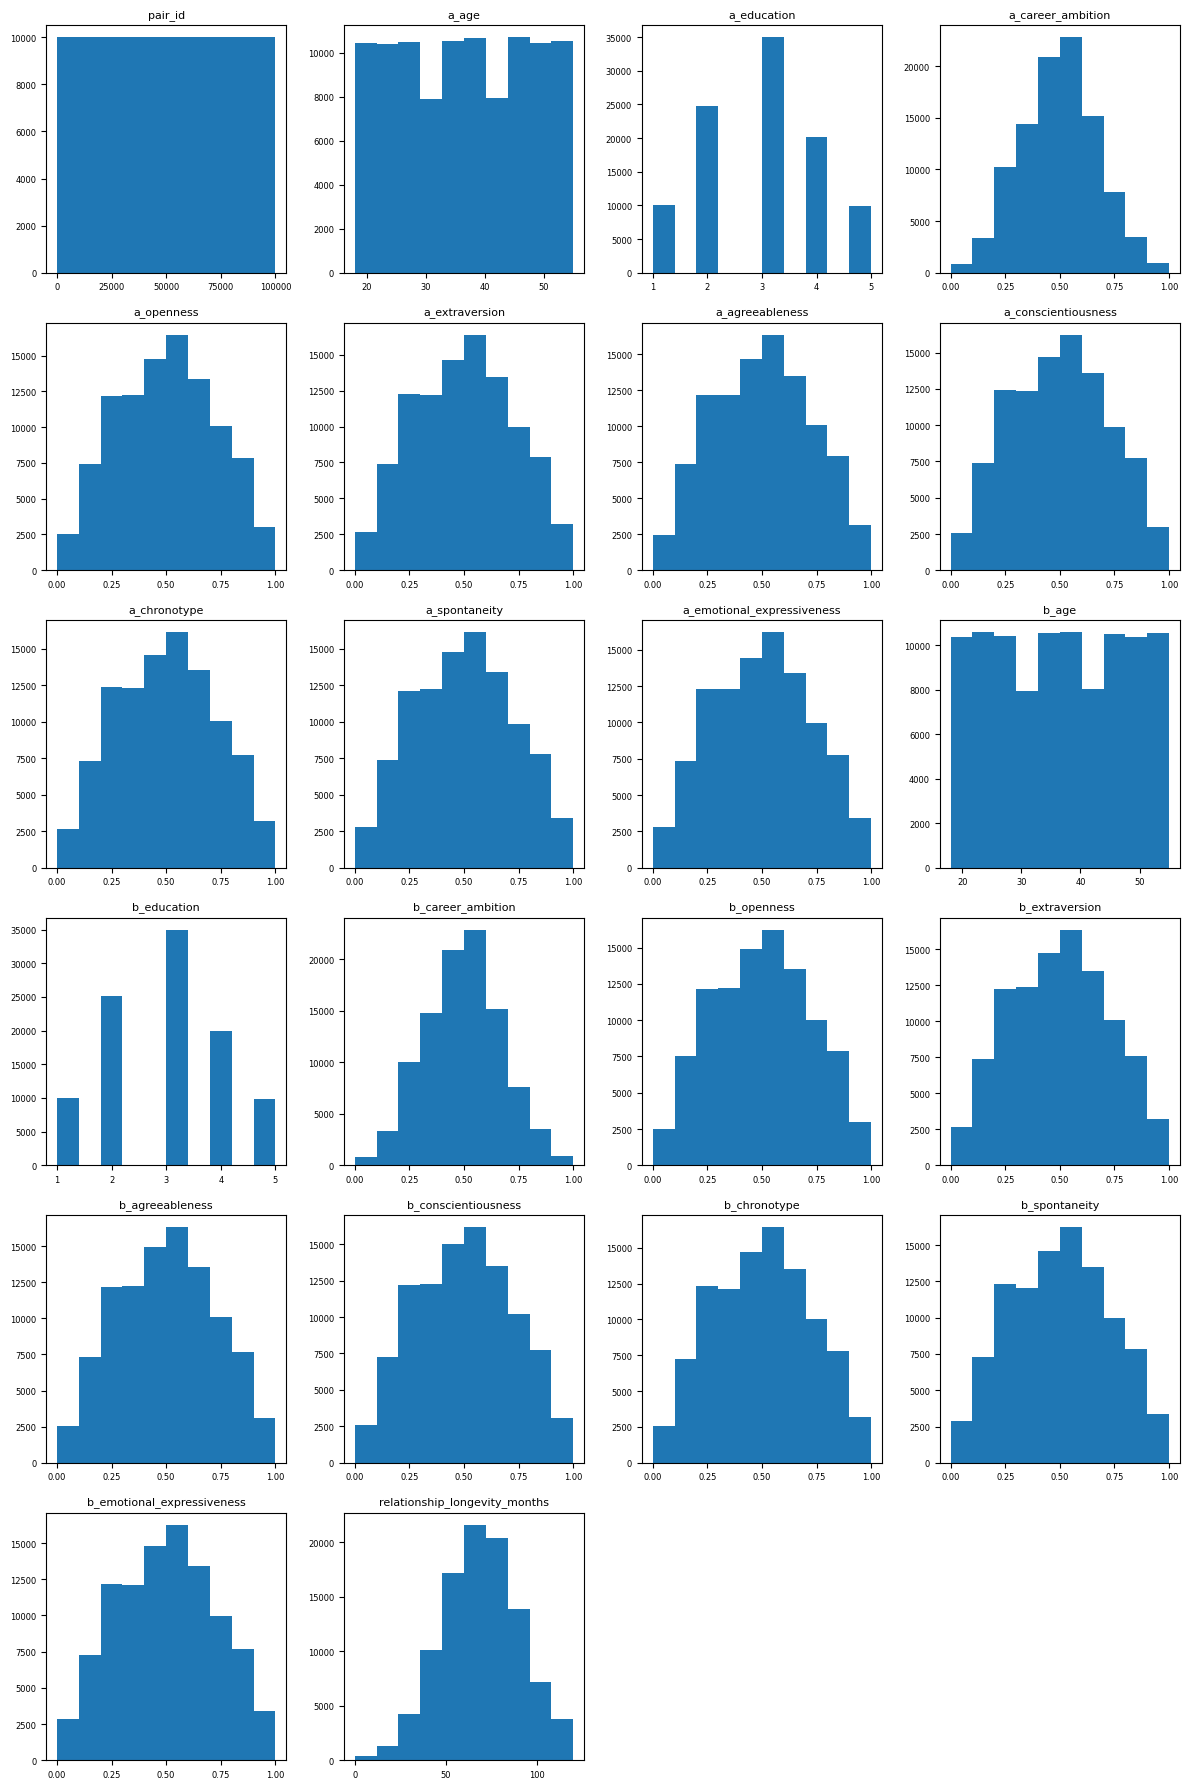

In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.hist(df[col].dropna(), bins=10)
    plt.title(col, fontsize=8)
    plt.xticks(fontsize=6)
    plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

The distributions seem a bit off (some gaps in the age distribution, assymetrical distribution of personal traits caracteristics). This database is generated and not based on real observations, which might be the reason for these oddities. However, the problem should not be that much of a disagreement for our current case study as the distribution are globally close to normale. 

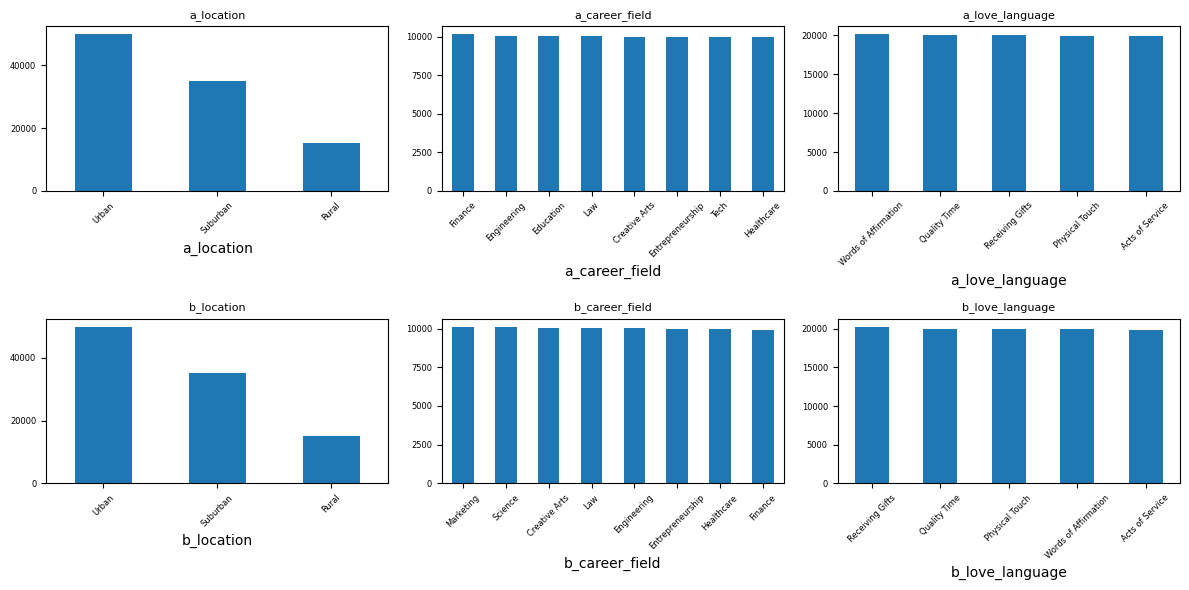

In [11]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "string"]
).columns

n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)

plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(categorical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    df[col].value_counts().head(8).plot(kind="bar")
    plt.title(col, fontsize=8)
    plt.xticks(fontsize=6, rotation=45)
    plt.yticks(fontsize=6)

plt.tight_layout()
plt.show()

Nothing to report

# Conclusion

We can conclude for now that the dataset is clean and exploitable for building a classic ML model (LinearRegression, RandomForest or LightGBM).